In [ ]:
# import sys
# !{sys.executable} -m pip install --upgrade fast_ml scikit-learn optuna seaborn==0.11 pandas_profiling

In [1]:
import numpy as np
import pandas as pd
import pandas_profiling
import matplotlib.pyplot as plt
import seaborn as sns
from fast_ml.model_development import train_valid_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, r2_score
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, GroupKFold, TimeSeriesSplit, LeaveOneOut
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import optuna

%matplotlib inline

/var/folders/tf/wxlbbyqn7_v7078r0z0skw280000gn/T/ipykernel_1618/4281295218.py:3: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling


### Загрузим данные

In [2]:
df = pd.read_csv('DiamondsPrices2022.csv')
df = df.drop(columns=['Unnamed: 0'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.profile_report()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
df[df['y'] > 10]

,carat,cut,color,clarity,depth,table,price,x,y,z
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
25998,4.01,Premium,I,I1,61.0,61.0,15223,10.14,10.10,6.17
27415,5.01,Fair,J,I1,65.5,59.0,18018,10.74,10.54,6.98
27630,4.50,Fair,J,I1,65.8,58.0,18531,10.23,10.16,6.72
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12


In [6]:
df[df['z'] > 10]

,carat,cut,color,clarity,depth,table,price,x,y,z
48410,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.8


In [7]:
len(df)

53943

In [10]:
df = df[(df['y'] < 30) & (df['z'] < 30)]

In [11]:
len(df)

53940

In [12]:
df[df['x'] < 0.1]

,carat,cut,color,clarity,depth,table,price,x,y,z
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.0,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.00,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.00,0.0
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.00,0.0
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.00,0.0
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.0,0.00,0.0
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.0,0.00,0.0


In [13]:
df.loc[df['x'] < 0.1, 'x'] = np.nan
df.loc[df['y'] < 0.1, 'y'] = np.nan
df.loc[df['z'] < 0.1, 'z'] = np.nan

In [14]:
df[df['x'] < 0.1]

,carat,cut,color,clarity,depth,table,price,x,y,z


## Разбиение датасета на обучение/тест
https://academy.yandex.ru/handbook/ml/article/kross-validaciya

In [15]:
X, y = df.drop(columns=['price']), df['price']

In [16]:
X.shape, y.shape

((53940, 9), (53940,))

### train test

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((43152, 9), (10788, 9), (43152,), (10788,))

<AxesSubplot: xlabel='price', ylabel='Density'>

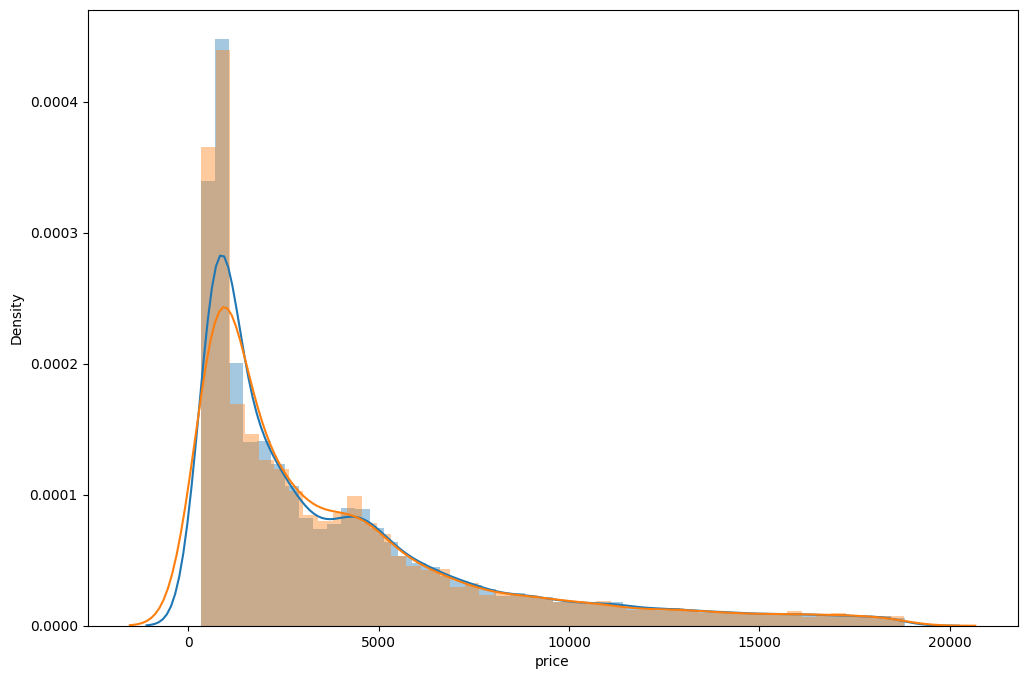

In [18]:
plt.figure(figsize=(12,8))
sns.distplot(y_train)
sns.distplot(y_test)

### train val test

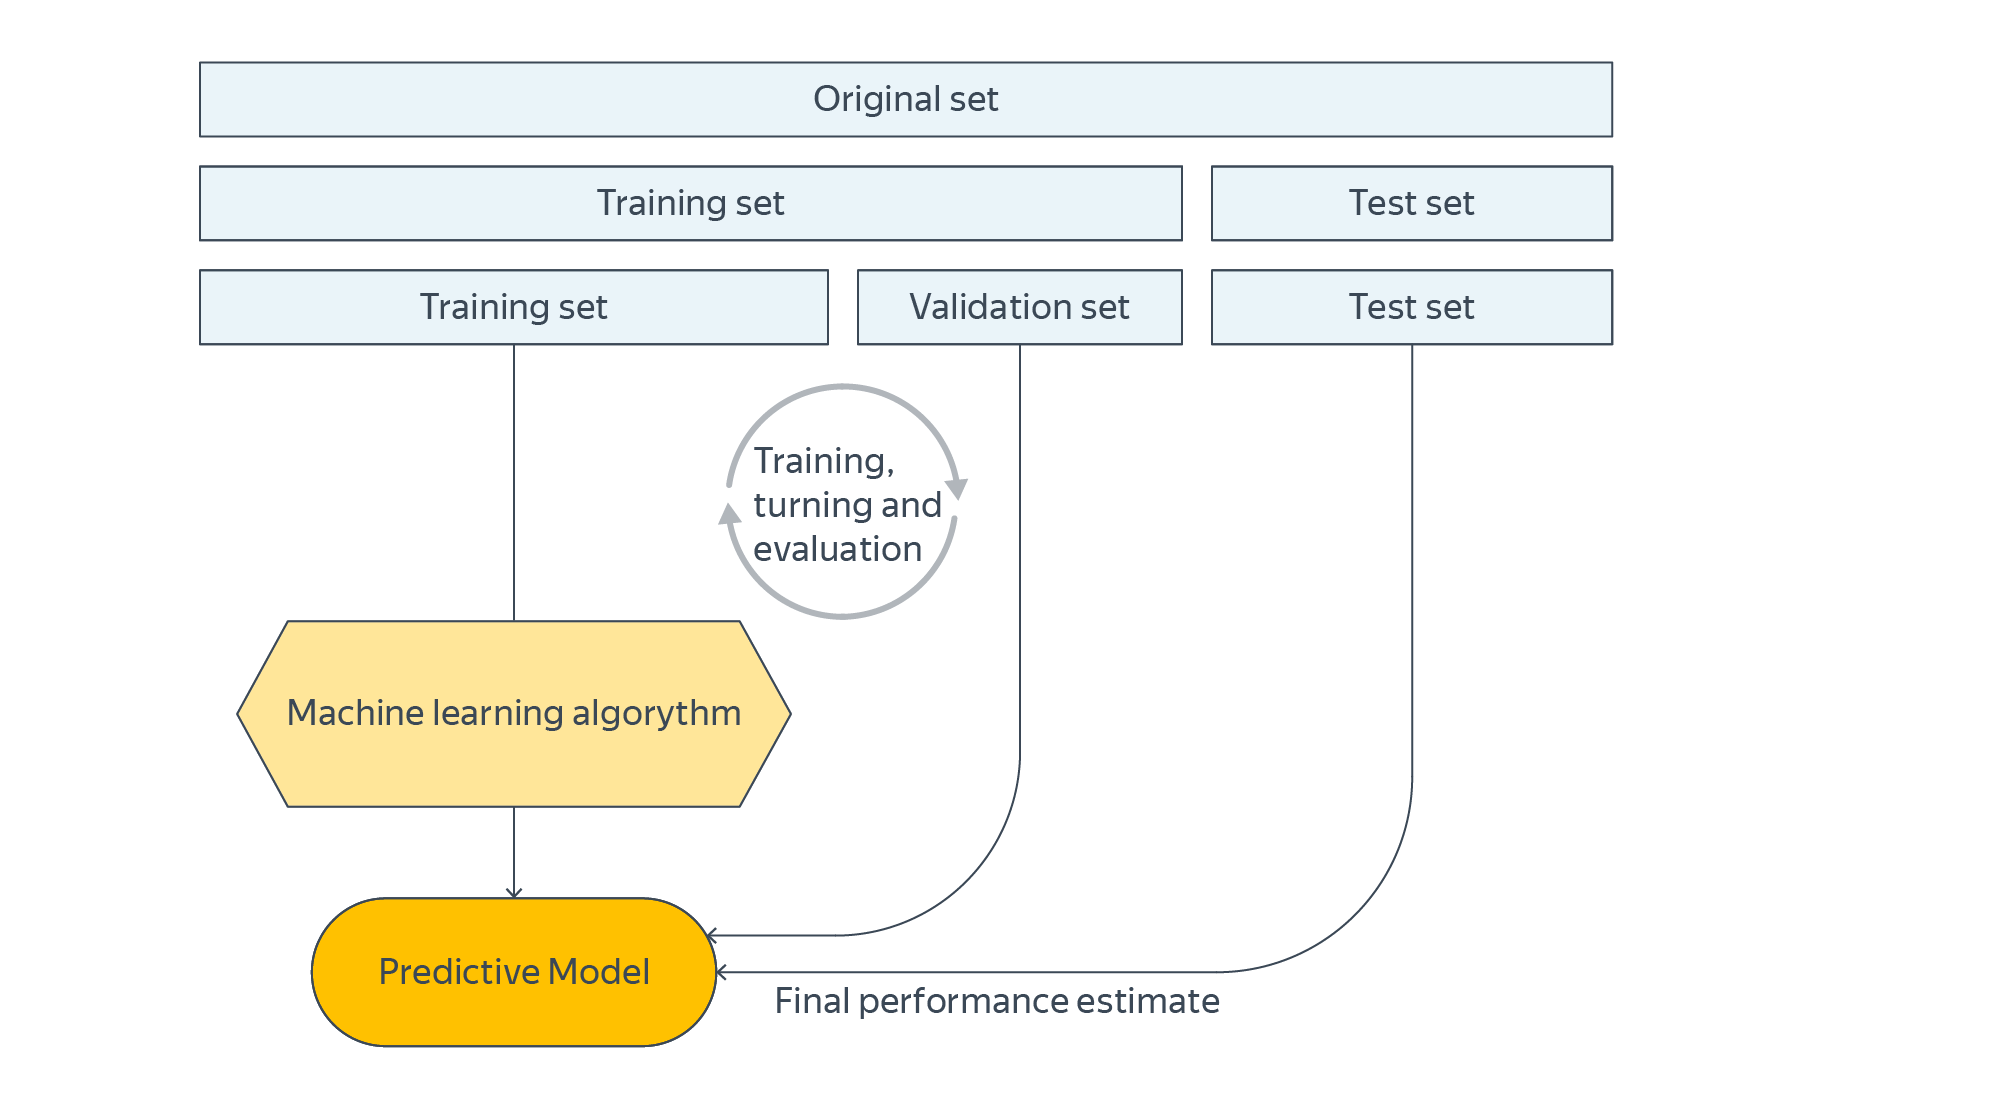

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.15/(1-0.15), 
    random_state=42
)

X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((37757, 9), (8092, 9), (8091, 9), (37757,), (8092,), (8091,))

In [20]:
X_train, y_train, X_valid, y_valid, X_test, y_test = train_valid_test_split(
    df, 'price', train_size=0.7, valid_size=0.15, test_size=0.15)

In [21]:
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((37758, 9), (8092, 9), (8091, 9), (37758,), (8092,), (8091,))

### Стратификация

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=X['cut']
)

In [35]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((43152, 9), (10788, 9), (43152,), (10788,))

In [36]:
X_train['cut'].value_counts() / len(X_train)

Ideal        0.399518
Premium      0.255678
Very Good    0.223999
Good         0.090958
Fair         0.029848
Name: cut, dtype: float64

In [37]:
X_test['cut'].value_counts() / len(X_test)

Ideal        0.399518
Premium      0.255747
Very Good    0.223953
Good         0.090934
Fair         0.029848
Name: cut, dtype: float64

<AxesSubplot: xlabel='cut', ylabel='Count'>

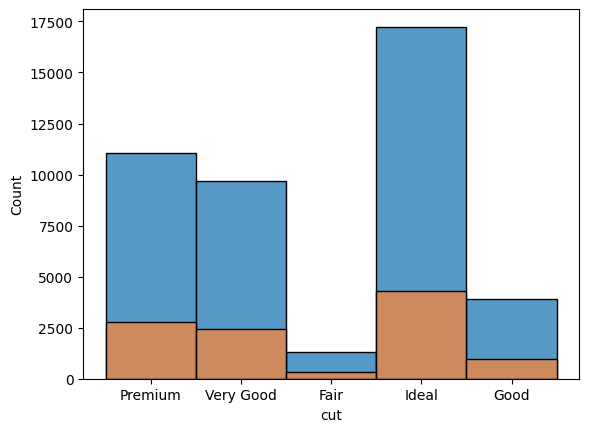

In [38]:
sns.histplot(x=X_train['cut'])
sns.histplot(x=X_test['cut'], color='#f5853b')

### K-fold

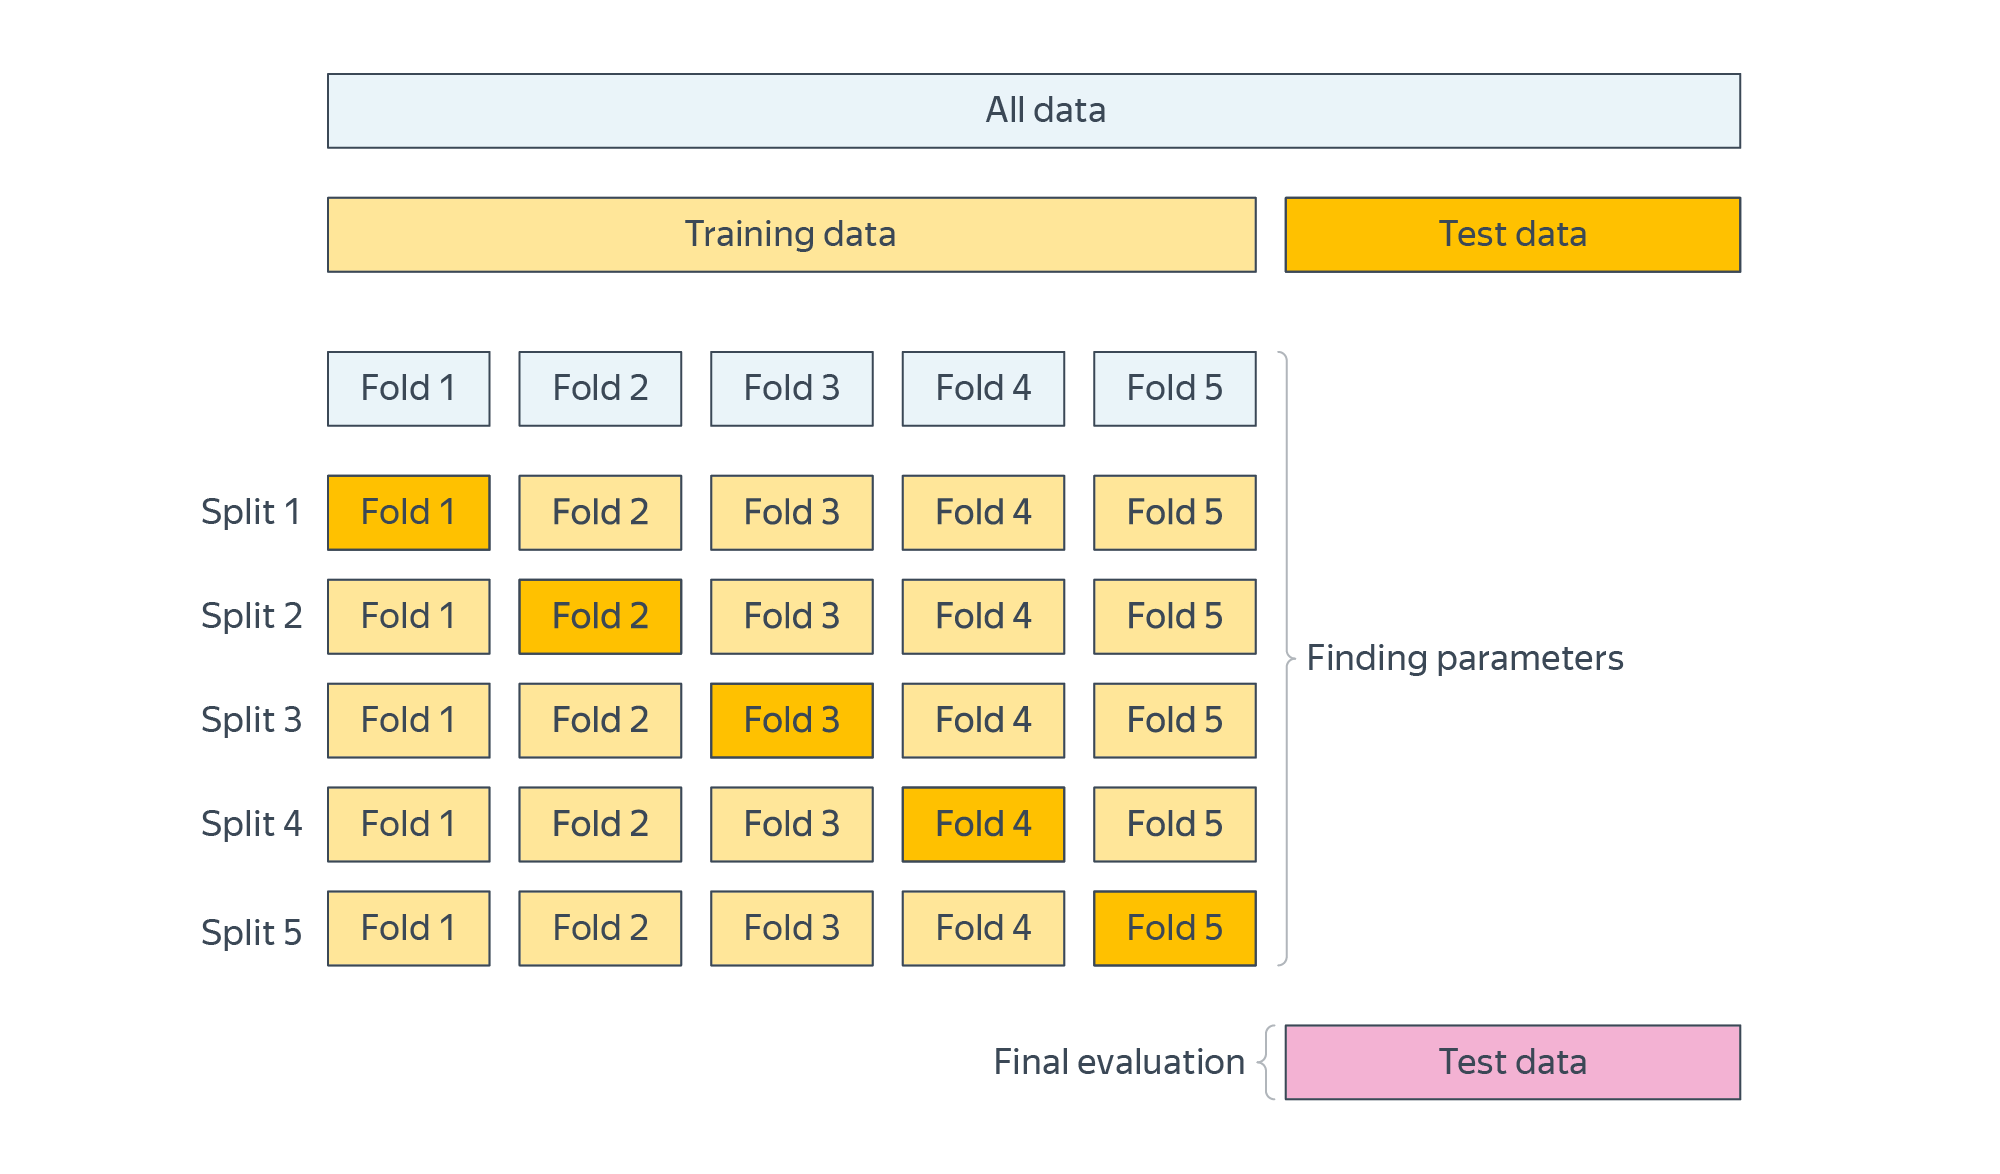

In [39]:
kf = KFold(n_splits=5, shuffle=True)

for train_index, test_index in kf.split(X):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

TRAIN: [    0     1     5 ... 53935 53938 53939] TEST: [    2     3     4 ... 53934 53936 53937]
TRAIN: [    0     1     2 ... 53937 53938 53939] TEST: [   11    15    36 ... 53925 53930 53932]
TRAIN: [    0     1     2 ... 53937 53938 53939] TEST: [    5     7     9 ... 53919 53923 53927]
TRAIN: [    0     1     2 ... 53937 53938 53939] TEST: [    6     8    14 ... 53924 53929 53931]
TRAIN: [    2     3     4 ... 53934 53936 53937] TEST: [    0     1    10 ... 53935 53938 53939]


### Leave-one-out

In [41]:
loo = LeaveOneOut()

X = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])
y = np.array([1, 2, 3, 4, 5])
for train_index, test_index in loo.split(X):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

TRAIN: [1 2 3 4] TEST: [0]
TRAIN: [0 2 3 4] TEST: [1]
TRAIN: [0 1 3 4] TEST: [2]
TRAIN: [0 1 2 4] TEST: [3]
TRAIN: [0 1 2 3] TEST: [4]


### Stratified K-fold

In [42]:
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])
skf = StratifiedKFold(n_splits=2)

for train_index, test_index in skf.split(X, y):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

TRAIN: [2 3 6 7] TEST: [0 1 4 5]
TRAIN: [0 1 4 5] TEST: [2 3 6 7]


In [46]:
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])
skf = KFold(n_splits=2, shuffle=True)

for train_index, test_index in skf.split(X, y):
    print("TRAIN:", y[train_index], train_index, "TEST:", y[test_index], test_index)

TRAIN: [0 0 0 1] [0 1 2 7] TEST: [0 1 1 1] [3 4 5 6]
TRAIN: [0 1 1 1] [3 4 5 6] TEST: [0 0 0 1] [0 1 2 7]


### TimeSeriesSplit

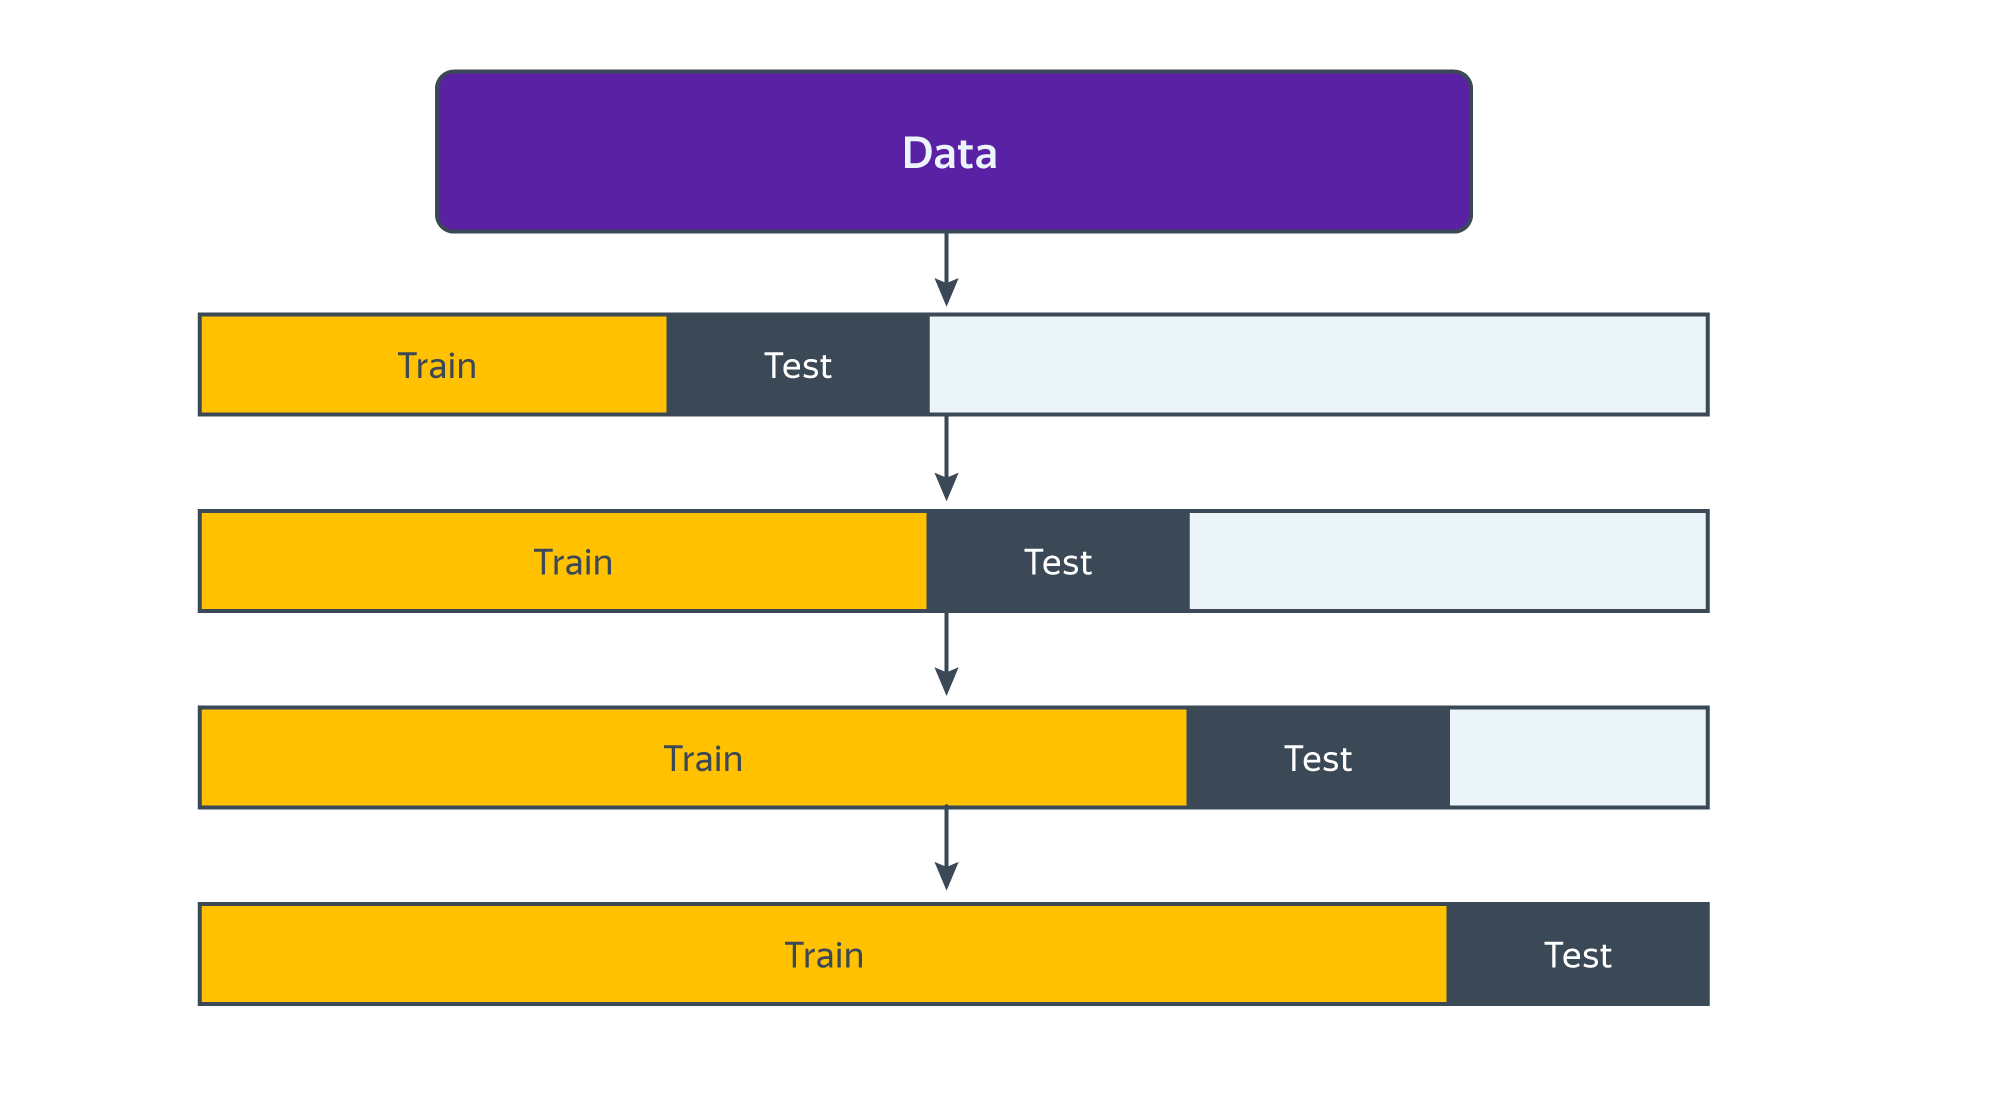

In [47]:
X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
y = np.array([1, 2, 3, 4, 5, 6])
tscv = TimeSeriesSplit()
print(tscv)
 
for train_index, test_index in tscv.split(X):
    print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
TRAIN: [0] TEST: [1]
TRAIN: [0 1] TEST: [2]
TRAIN: [0 1 2] TEST: [3]
TRAIN: [0 1 2 3] TEST: [4]
TRAIN: [0 1 2 3 4] TEST: [5]


## Нормализация данных и Pipeline

In [48]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [49]:
X, y = df.drop(columns=['price']), df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.15/(1-0.15), 
    random_state=42
)

In [ ]:
StandardScaler(), MinMaxScaler(), RobustScaler()

In [ ]:
SimpleImputer(), KNNImputer()

In [50]:
df['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [95]:
OneHotEncoder().fit_transform(df['cut'].values.reshape(-1, 1)).todense()

matrix([[0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0.],
        ...,
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]])

In [51]:
numeric_features = ["carat", "depth", "table", "x", "y", "z"]
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_features = ["cut", "color", "clarity"]
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [79]:
X_train_norm = preprocessor.fit_transform(X_train)

In [78]:
X_train.iloc[0]

carat        0.8
cut        Ideal
color          F
clarity      SI1
depth       60.5
table       57.0
x           6.02
y           6.07
z           3.66
Name: 3578, dtype: object

In [96]:
X_train_norm[0]

array([ 0.00497359, -0.87166977, -0.20645227,  0.25740589,  0.30242035,
        0.17420536,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ])

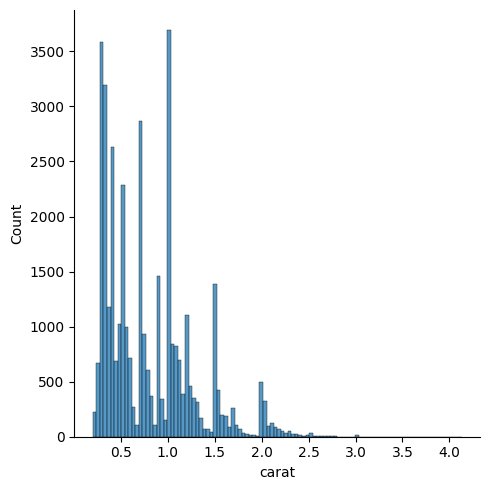

In [97]:
sns.displot(X_train['carat'])

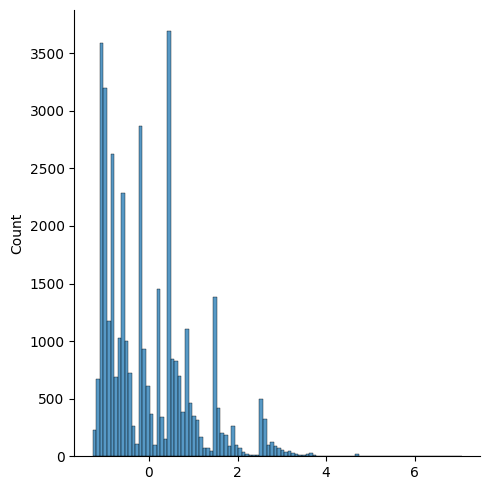

In [91]:
sns.displot(X_train_norm[:, 0])

In [52]:
regressor = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor())]
)
regressor

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carat', 'depth', 'table',
                                                   'x', 'y', 'z']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cut', 'color',
                                                   'clarity'])])),
                ('regressor', RandomForestRegressor())])

In [54]:
regressor.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carat', 'depth', 'table',
                                                   'x', 'y', 'z']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cut', 'color',
                                                   'clarity'])])),
                ('regressor', RandomForestRegressor())])

In [56]:
y_pred = regressor.predict(X_test)

In [57]:
mean_squared_error(y_test, y_pred, squared=False)  # MSE -> RMSE

538.5156385289026

In [58]:
r2_score(y_test, y_pred)

0.9818808881389108

<AxesSubplot: xlabel='price', ylabel='Density'>

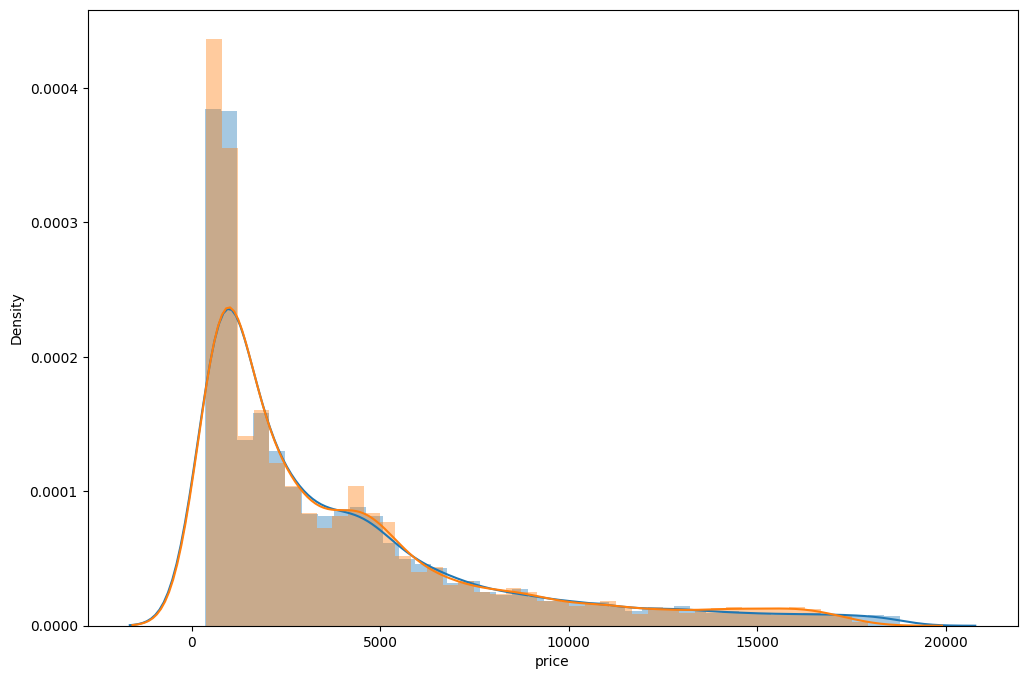

In [59]:
plt.figure(figsize=(12,8))
sns.distplot(y_test)
sns.distplot(y_pred)

## Подбор гиперпараметров
https://academy.yandex.ru/handbook/ml/article/podbor-giperparametrov

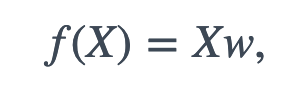  
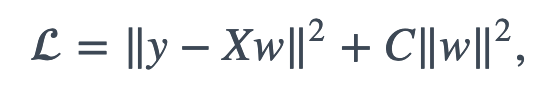

In [ ]:
Ridge(), Lasso()

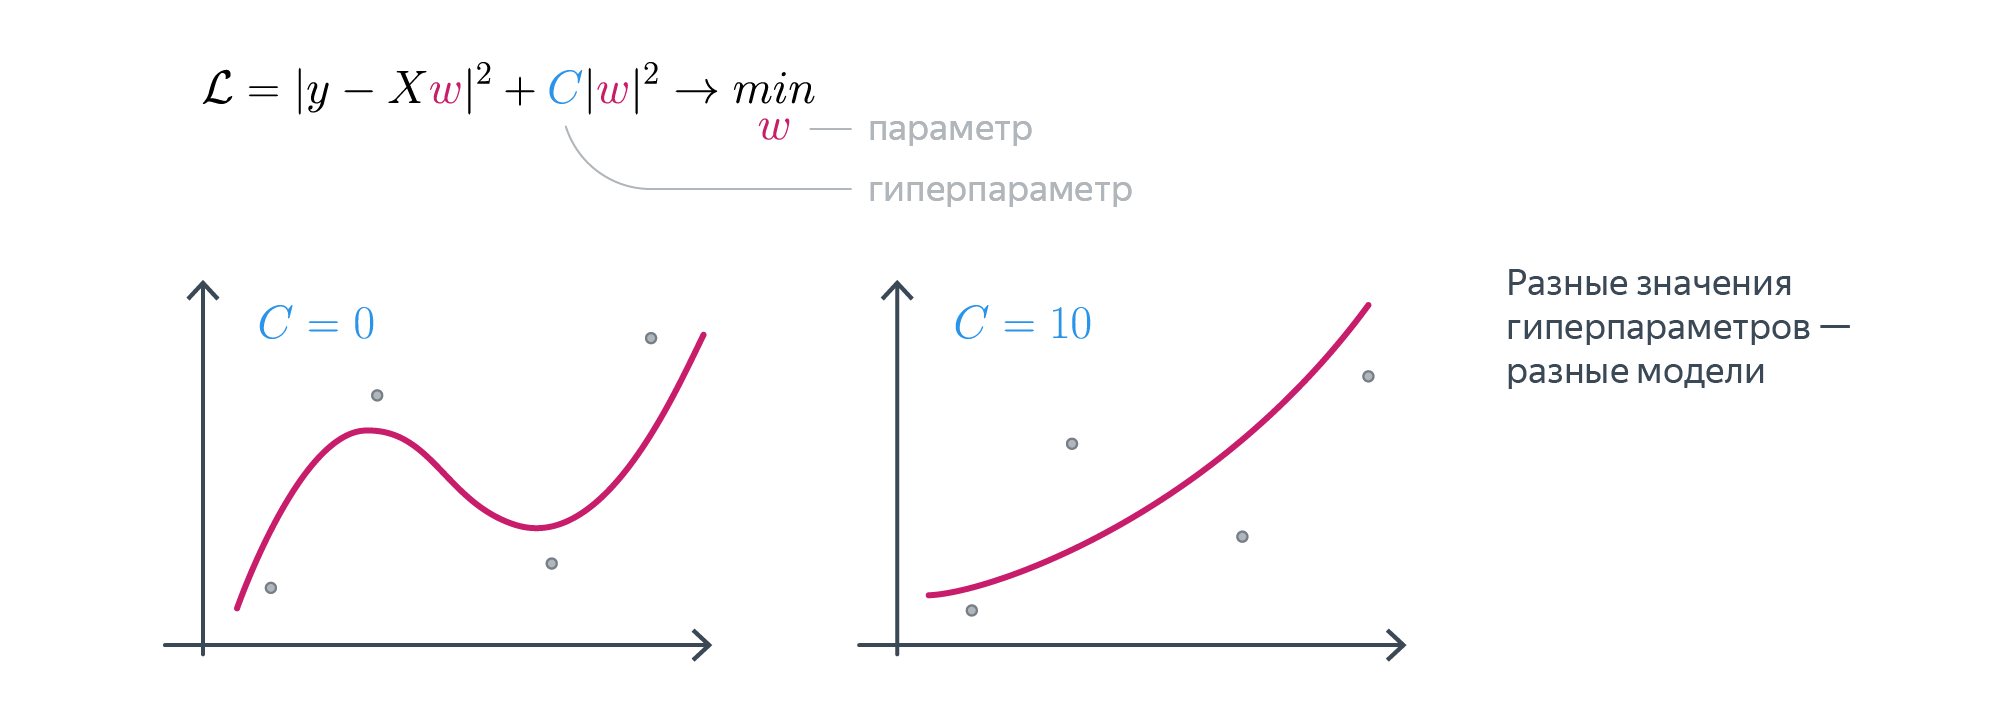

### Какие бывают гиперпараметры

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge  
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html?highlight=randomforest#sklearn.ensemble.RandomForestRegressor  
https://lightgbm.readthedocs.io/en/latest/Parameters.html  

In [ ]:
params = {
    'application': 'regression',
    'boosting': 'gbdt',
    'metric': 'rmse',
    'n_jobs': 4,
    'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 10.0),
    'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 10.0),
    'num_leaves': trial.suggest_int('num_leaves', 11, 333),
    'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    'max_depth': trial.suggest_int('max_depth', 5, 64),
    'learning_rate': trial.suggest_categorical('learning_rate', [0.005, 0.01, 0.02, 0.05, 0.1]),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 0.5),
    'n_estimators': trial.suggest_int('n_estimators', 2000, 8000),
    'cat_smooth' : trial.suggest_int('cat_smooth', 10, 100),
    'cat_l2': trial.suggest_int('cat_l2', 1, 20),
    'min_data_per_group': trial.suggest_int('min_data_per_group', 50, 200),
}

### Подбираем ручками

In [60]:
params = {
    'regressor__bootstrap': [True, False],
    'regressor__max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
    'regressor__max_features': ['auto', 'sqrt'],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
}

In [61]:
regressor = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor(n_estimators=200))]
)

regressor.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carat', 'depth', 'table',
                                                   'x', 'y', 'z']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['cut', 'color',
                                                   'clarity'])])),
                ('regressor', RandomForestRegressor(n_estimators=200))])

In [62]:
y_pred = regressor.predict(X_test)

In [63]:
mean_squared_error(y_test, y_pred, squared=False)

537.5830572494925

In [64]:
r2_score(y_test, y_pred)

0.9819435898026876

### Grid Search

In [ ]:
rf_random = GridSearchCV(estimator=regressor, param_distributions=params, 
                         n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)

In [ ]:
rf_random.fit(X_train, y_train)

### Random Search

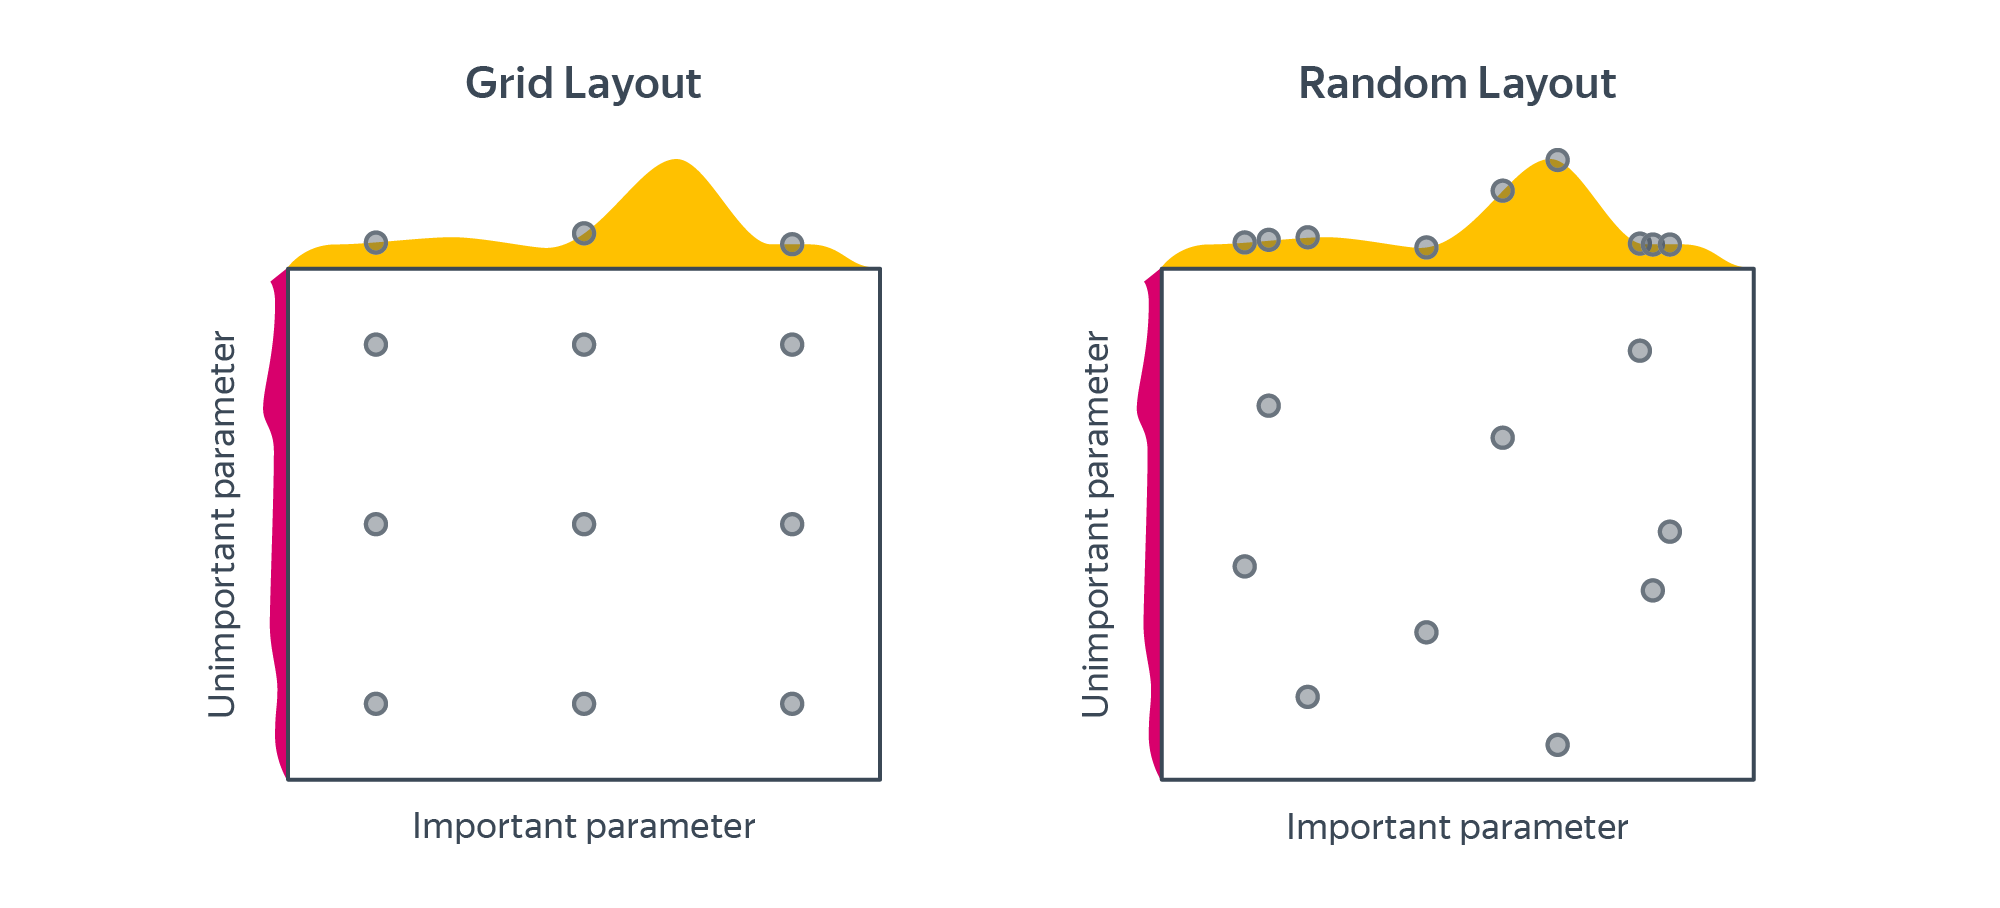

In [ ]:
rf_random = RandomizedSearchCV(estimator=regressor, param_distributions=params, 
                               n_iter=30, cv=3, verbose=2, random_state=42, n_jobs=-1)

In [ ]:
rf_random.fit(X_train, y_train)

### Байесовская оптимизация

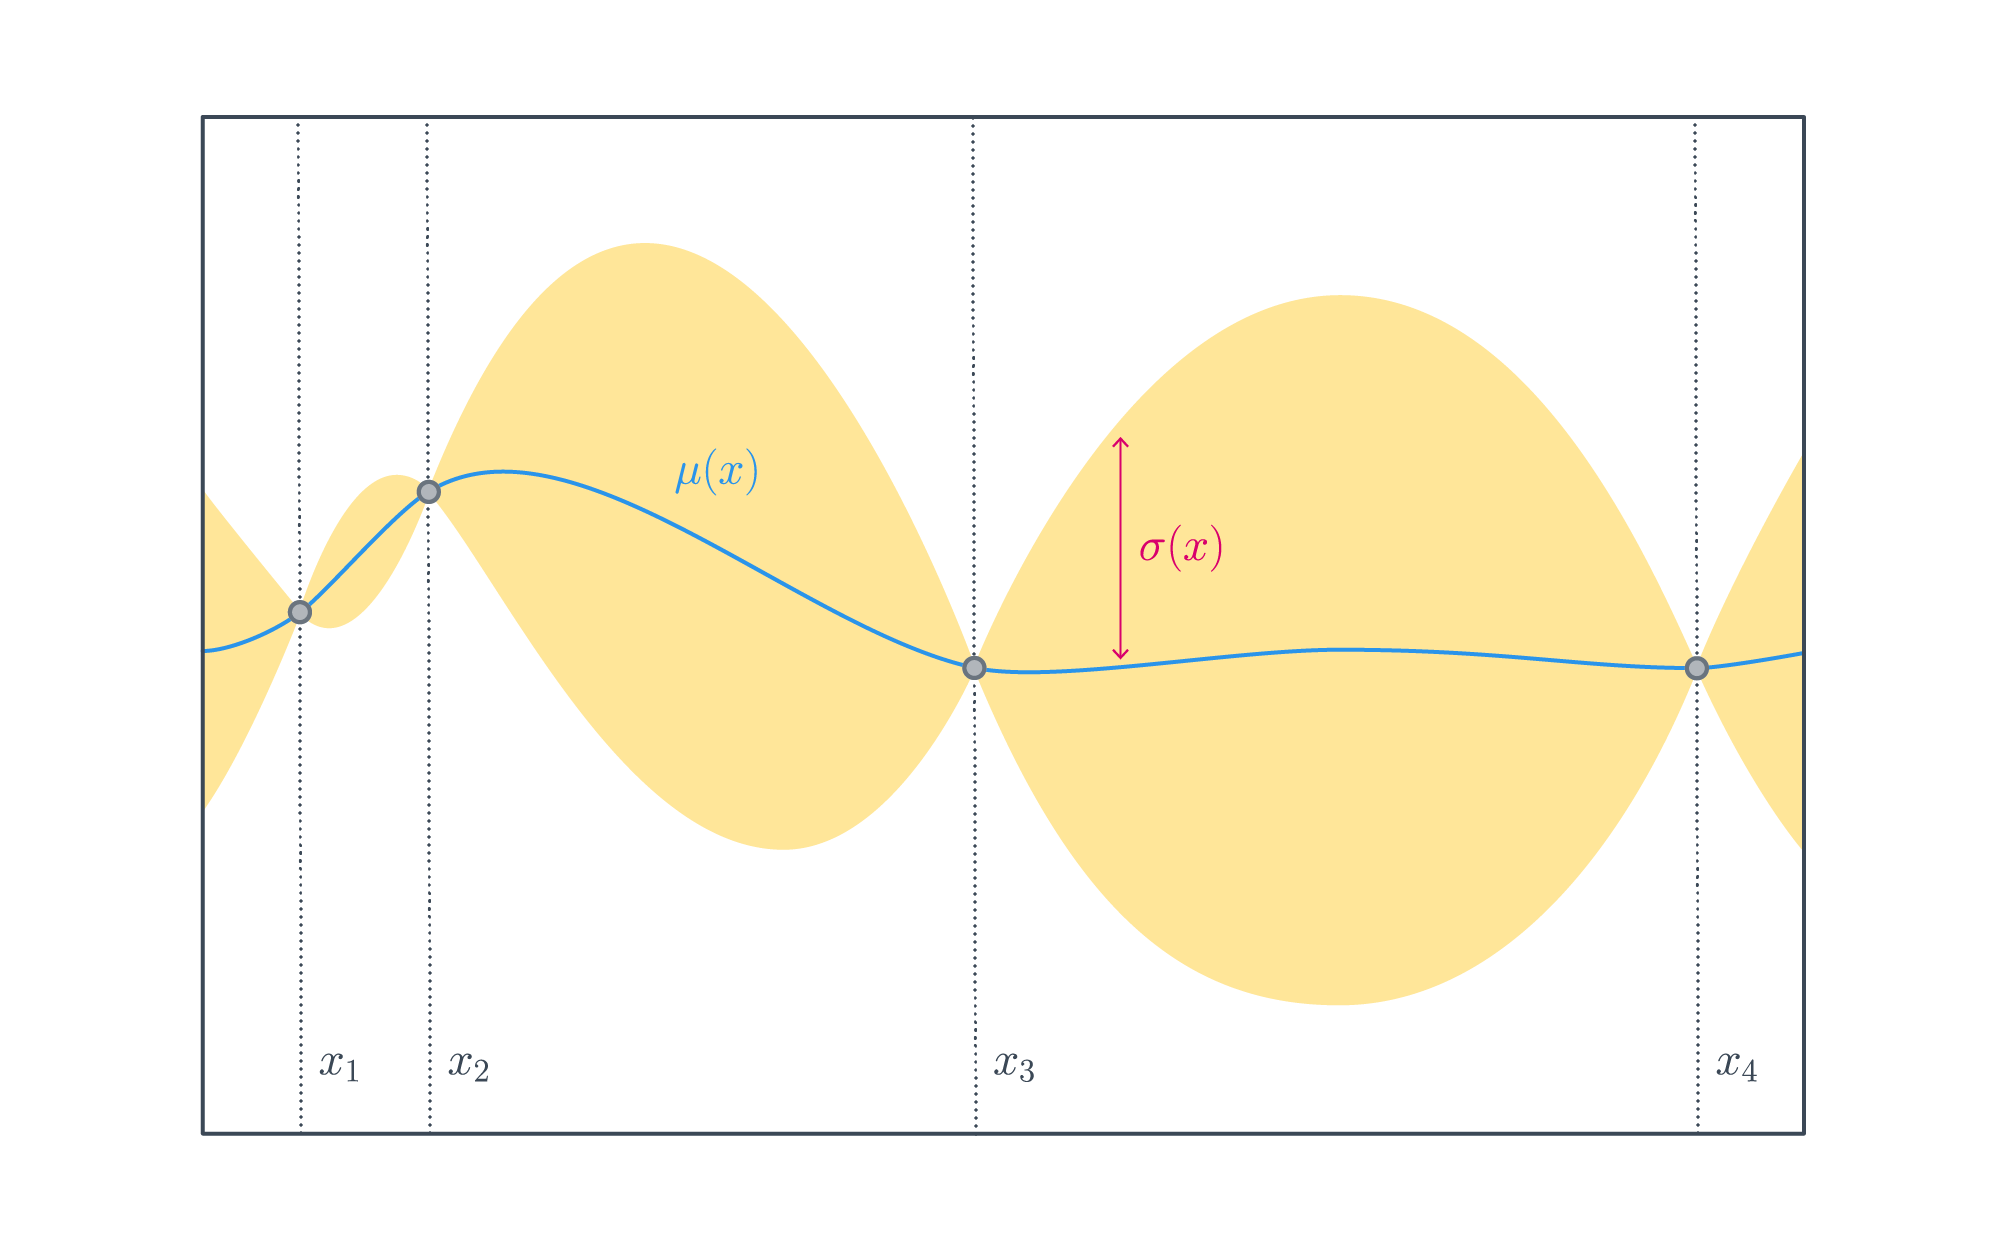

In [65]:
X, y = df.drop(columns=['price']), df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.15/(1-0.15), 
    random_state=42
)

In [66]:
def objective(trial):
    params = {
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'max_depth': trial.suggest_int('max_depth', 100, 800),
        'max_features': trial.suggest_categorical('max_features', ['auto', 'sqrt']),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 5),
        'min_samples_split': trial.suggest_int('min_samples_split', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 800)
    }
    
    regressor = Pipeline(
        steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor(**params))]
    )

    regressor.fit(X_train, y_train)
    
    y_pred = regressor.predict(X_val)
    
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    
    return rmse

In [67]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)
print('Number of finished trials: ', len(study.trials))
print('Best trial: ', study.best_trial.params)
print('Best value: ', study.best_value)

[I 2023-05-27 13:15:12,256] A new study created in memory with name: no-name-bf7fb8a5-1a53-4973-b596-72a238765093
[I 2023-05-27 13:15:19,584] Trial 0 finished with value: 617.5111912738996 and parameters: {'bootstrap': False, 'max_depth': 236, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 9, 'n_estimators': 139}. Best is trial 0 with value: 617.5111912738996.
[I 2023-05-27 13:15:39,460] Trial 1 finished with value: 600.4480436578856 and parameters: {'bootstrap': False, 'max_depth': 284, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 374}. Best is trial 1 with value: 600.4480436578856.
[I 2023-05-27 13:16:16,734] Trial 2 finished with value: 608.876581648189 and parameters: {'bootstrap': False, 'max_depth': 423, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 706}. Best is trial 1 with value: 600.4480436578856.
[I 2023-05-27 13:16:43,869] Trial 3 finished with value: 599.682465544966 an

Number of finished trials:  15
Best trial:  {'bootstrap': True, 'max_depth': 348, 'max_features': 'auto', 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 511}
Best value:  563.9988860100909


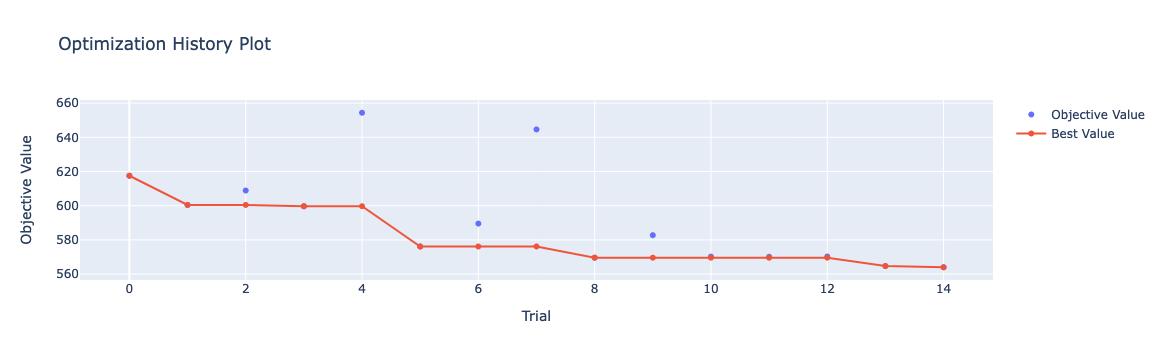

In [68]:
optuna.visualization.plot_optimization_history(study)#.write_html('optuna_optimization_history.html', include_plotlyjs='cdn')

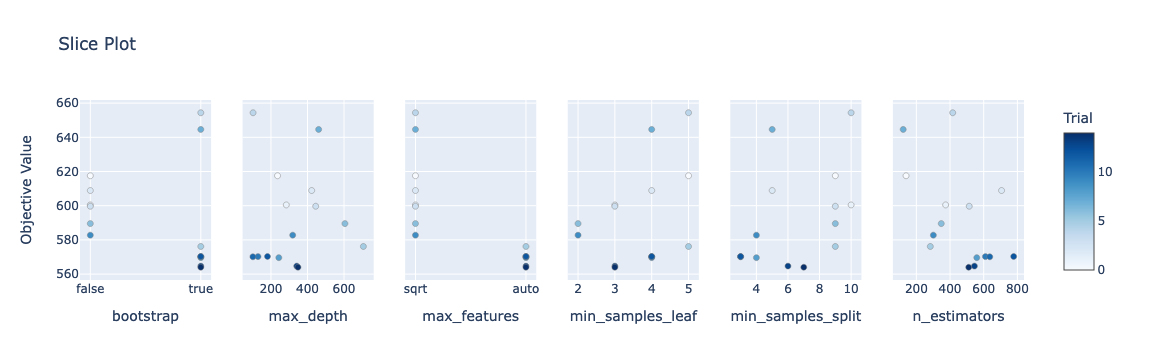

In [69]:
optuna.visualization.plot_slice(study)#.write_html('optuna_optimization_history.html', include_plotlyjs='cdn')

In [70]:
study.best_trial.params

{'bootstrap': True,
 'max_depth': 348,
 'max_features': 'auto',
 'min_samples_leaf': 3,
 'min_samples_split': 7,
 'n_estimators': 511}

In [71]:
y_pred = regressor.predict(X_test)

In [72]:
mean_squared_error(y_test, y_pred, squared=False)

537.5830572494925

In [73]:
r2_score(y_test, y_pred)

0.9819435898026876

## Вопросы

1. Какие требования предъявляются к объему выборки в машинном обучении? Например, можно ли работать с социологическими опросами на 1000/1500 человек? Или все зависит от количества признаков? Может быть существует какая-нибудь универсальная формула для расчета выборки?

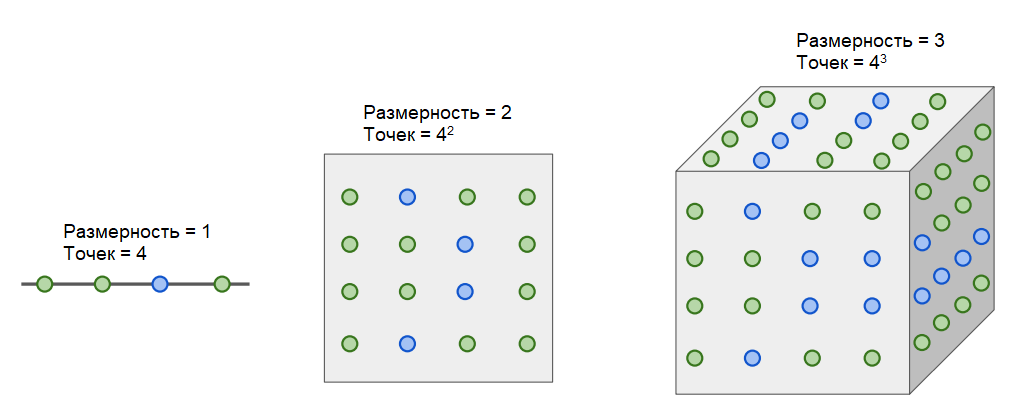

2. Можно чуточку подробнее о том, каким образом контролировать переобучение/недообучение модели?

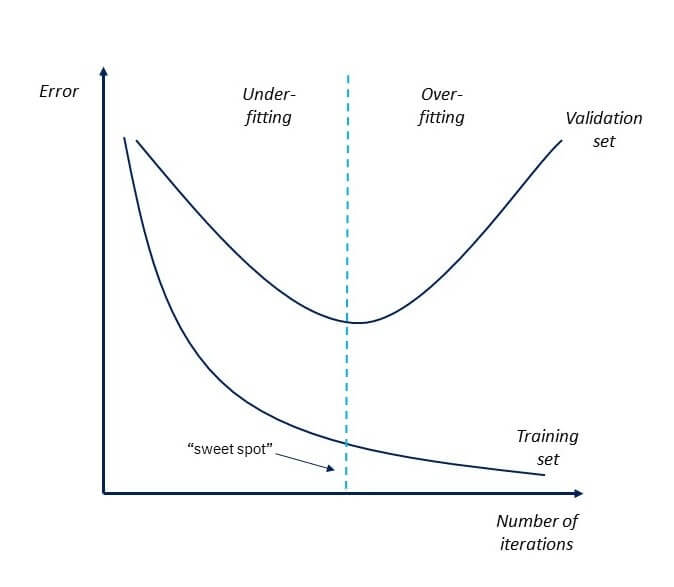